Compare classification performance through the different subsets of features across multiple years


In [2]:
import sys
import os
import itertools
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

import ee
ee.Initialize(project='mapbiomas-india')

# Add parent directory to path to import the module
sys.path.append('..')
from multi_parameters_runs_and_analysis.feature_selection_module import EEFeatureSelectionModule

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [18]:
# Load dataset metadata
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')
region_numbers_df = pd.read_csv('data/regions_area.csv')
legends_df = pd.read_csv('data/class_legend.csv')

In [19]:
# YEARS = [1995, 2005, 2015, 2024]
YEARS = list(range(1995,2025,3))

In [88]:
 list(range(1995,2025,3))

[1995, 1998, 2001, 2004, 2007, 2010, 2013, 2016, 2019, 2022]

In [75]:
len(YEARS)

10

In [4]:
# classwise_samples_scaled_2k_10k

Scenario 1 & 2

In [ ]:
# 1. Define your experiment space
regions = ['HIM', 'IGP', 'DES', 'PEN', 'NEI', 'WGR', 'ICR']
region_id_map = {'HIM': 1, 'IGP': 2, 'DES': 3, 'PEN': 4, 'NEI': 5, 'WGR': 6, 'ICR': 7}

# Define regional sample versions 
# (Update these values with your actual version strings)
sample_version_map = {
    'HIM': '4', 
    'IGP': '5', 
    'DES': '7', 
    'PEN': '5', 
    'NEI': '5', 
    'WGR': '3', 
    'ICR': '4'
}

# Define parameters
param_grid = {
    'sample_strategy': ['scaled'], 
    # 'sample_strategy' : ['scaled'],
    # 'sample_strategy' : ['default'],
    'n_trees': [50],               
    'features': ['all', 'static_16'],
    'minLeafPopulation' : [5]         
}

# Generate parameter combinations
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

# Load the default sample distributions
# default_samples_df = pd.read_csv('default_samples_2000_total.csv',delimiter='\t')

experiment_logs = []
classes = classwise_samples_scaled_2k_10k['classification_class_code'].tolist()

for region in regions:
    region_id = region_id_map[region]
    current_sample_version = sample_version_map[region]
    
    # Extract the scaled target counts for this region
    scaled_counts = classwise_samples_scaled_2k_10k[region].tolist()
    
    # Extract the default target counts for this region from the newly referenced CSV
    # (Using .tolist() assumes the rows in default_samples_df are in the exact same order as classes)
    # default_counts = default_samples_df[region].tolist()
    
    # Format lists for the EE module's load_and_balance_data()
    scaled_balance_list = [[int(c), int(s)] for c, s in zip(classes, scaled_counts)]
    # default_balance_list = [[int(c), int(s)] for c, s in zip(classes, default_counts)]

    for year in YEARS:
        for params in param_combinations:
            print(f"Executing: {region} (v{current_sample_version}) | Year {year} | Params: {params}")
            
            # Initialize the EE module 
            ee_module = EEFeatureSelectionModule(
                region_id=region_id, 
                year=year, 
                sample_version_in=current_sample_version, 
                number_of_trees=params['n_trees'],
                min_leaf_population=params['minLeafPopulation']
            )
            
            # Apply sampling strategy
            if params['sample_strategy'] == 'scaled':
                ee_module.load_and_balance_data(scaled_balance_list)
            # else:
            #     ee_module.load_and_balance_data(default_balance_list)
                
            # Determine Feature List
            if params['features'] == 'all':
                all_features = ee_module.training_partition.first().propertyNames()
                features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
                features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
                trained_classifier, accuracy, f1_weighted, f1_macro,y_true, y_pred,importance_df = ee_module.evaluate_model(features_list,return_importance=True)

                importance_df['region'] = region
                importance_df['year'] = year
                importance_df['sample_version'] = current_sample_version

                # Determine if the header should be written
                file_path = f'data/feature_importance/feature_importance_{region}_v{current_sample_version}_{year}.csv'
                file_exists = os.path.exists(file_path)

                # Append data dynamically
                importance_df.to_csv(file_path, index=False)
                # importance_df.to_csv(file_path, mode='a', index=False, header=not file_exists)
                       
            else:
                features_list = ee_module.default_bands
                trained_classifier, accuracy, f1_weighted, f1_macro, y_true, y_pred = ee_module.evaluate_model(features_list)
                
            # Train and Evaluate
            # trained_classifier, accuracy, f1_weighted, y_true, y_pred = ee_module.evaluate_model(features_list)
            
            # Log results
            experiment_logs.append({
                'region': region,
                'year': year,
                'sample_version': current_sample_version,
                'sample_strategy': params['sample_strategy'],
                'n_trees': params['n_trees'],
                'features': params['features'],
                'accuracy': accuracy,
                'f1_weighted': f1_weighted,
                'f1_macro': f1_macro
            })

# Convert to DataFrame
results_df = pd.DataFrame(experiment_logs)

In [6]:
results_path = os.path.join('data','groupwise_runs_multiyear.csv')
results_df.to_csv(results_path, index=False)
# results_df.to_csv(results_path, mode='a', index=False, header=not results_path)

Scenario 3 & 4

In [7]:
import glob
from pathlib import Path

In [8]:
def aggregate_regional_importance(input_dir: str, output_dir: str):
    """Aggregates yearly feature importance by region and calculates temporal stability."""
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Matches the naming convention: feature_importance_HIM_v4_2024.csv
    all_files = glob.glob(os.path.join(input_dir, "feature_importance_*_*_*.csv"))
    
    file_groups = {}
    for filepath in all_files:
        filename = os.path.basename(filepath)
        # Strip the year suffix: 'feature_importance_HIM_v4_2024' -> 'feature_importance_HIM_v4'
        base_name = "_".join(filename.replace(".csv", "").split("_")[:-1])
        file_groups.setdefault(base_name, []).append(filepath)
        
    for base_name, files in file_groups.items():
        # Read and concatenate all yearly files for the specific region/version
        df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
        
        # Calculate median for ranking, and std for tracking temporal stability
        agg_df = (df.groupby("band")["importance"]
                  .agg(importance_median="median", importance_std="std")
                  .reset_index()
                  .sort_values(by="importance_median", ascending=False))
                  
        # Guard against regions that might only have one year of data
        agg_df["importance_std"] = agg_df["importance_std"].fillna(0)
                  
        out_path = os.path.join(output_dir, f"{base_name}.csv")
        agg_df.to_csv(out_path, index=False)

In [9]:
aggregate_regional_importance(input_dir = 'data/feature_importance',output_dir = 'data/feature_importance/aggregated/')

In [18]:
# 1. Define your experiment space
regions = ['HIM', 'IGP', 'DES', 'PEN', 'NEI', 'WGR', 'ICR']

region_id_map = {'HIM': 1, 'IGP': 2, 'DES': 3, 'PEN': 4, 'NEI': 5, 'WGR': 6, 'ICR': 7}

sample_version_map = {
    'HIM': '4', 'IGP': '5', 'DES': '7', 'PEN': '5', 'NEI': '5', 'WGR': '3', 'ICR': '4'
}

param_grid = {
    'sample_strategy': ['scaled'], 
    'n_trees': [50],               
    'features': ['top_N'],
    'minLeafPopulation' : [5]         
}

# Keep num_features as default
TOP_N_FEATURES = 20

keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
experiment_logs = []
classes = classwise_samples_scaled_2k_10k['classification_class_code'].tolist()

for region in regions:
    region_id = region_id_map[region]
    current_sample_version = sample_version_map[region]
    
    # Extract the scaled target counts for this region
    scaled_counts = classwise_samples_scaled_2k_10k[region].tolist()
    
    # Extract the default target counts for this region from the newly referenced CSV
    # (Using .tolist() assumes the rows in default_samples_df are in the exact same order as classes)
    # default_counts = default_samples_df[region].tolist()
    
    # Format lists for the EE module's load_and_balance_data()
    scaled_balance_list = [[int(c), int(s)] for c, s in zip(classes, scaled_counts)]
    # default_balance_list = [[int(c), int(s)] for c, s in zip(classes, default_counts)]

    for year in YEARS:
        for params in param_combinations:
            print(f"Executing: {region} (v{current_sample_version}) | Year {year} | Params: {params}")
            
            # Initialize the EE module 
            ee_module = EEFeatureSelectionModule(
                region_id=region_id, 
                year=year, 
                sample_version_in=current_sample_version, 
                number_of_trees=params['n_trees'],
                min_leaf_population=params['minLeafPopulation']
            )
            
            # Apply sampling strategy
            if params['sample_strategy'] == 'scaled':
                ee_module.load_and_balance_data(scaled_balance_list)
            # else:
            #     ee_module.load_and_balance_data(default_balance_list)
                
            # Determine Feature List
            if params['features'] == 'all':
                all_features = ee_module.training_partition.first().propertyNames()
                features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
                features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
                trained_classifier, accuracy, f1_weighted, f1_macro,y_true, y_pred,importance_df = ee_module.evaluate_model(features_list,return_importance=True)

                importance_df['region'] = region
                importance_df['year'] = year
                importance_df['sample_version'] = current_sample_version

                # Determine if the header should be written
                file_path = f'data/feature_importance/feature_importance_{region}_v{current_sample_version}_{year}.csv'
                file_exists = os.path.exists(file_path)

                # Append data dynamically
                importance_df.to_csv(file_path, index=False)
                # importance_df.to_csv(file_path, mode='a', index=False, header=not file_exists)
            elif params['features'] == 'top_N':
                # Read aggregated file like feature_importance_DES_v7.csv
                agg_file_path = f'data/feature_importance/aggregated/feature_importance_{region}_v{current_sample_version}.csv'
                
                if os.path.exists(agg_file_path):
                    agg_df = pd.read_csv(agg_file_path)
                    # Slice the top N features based on the aggregated median importance
                    features_list = agg_df.sort_values(by="importance_median", ascending=False)['band'].head(TOP_N_FEATURES).tolist()
                # else:
                #     print(f"Warning: {agg_file_path} not found. Defaulting to standard bands.")
                #     features_list = ee_module.default_bands
                    
                    trained_classifier, accuracy, f1_weighted, f1_macro, y_true, y_pred = ee_module.evaluate_model(features_list)         
            else:
                features_list = ee_module.default_bands
                trained_classifier, accuracy, f1_weighted, f1_macro, y_true, y_pred = ee_module.evaluate_model(features_list)
                
            # Train and Evaluate
            # trained_classifier, accuracy, f1_weighted, y_true, y_pred = ee_module.evaluate_model(features_list)
            
            # Log results
            experiment_logs.append({
                'region': region,
                'year': year,
                'sample_version': current_sample_version,
                'sample_strategy': params['sample_strategy'],
                'n_trees': params['n_trees'],
                'features': params['features'],
                'accuracy': accuracy,
                'f1_weighted': f1_weighted,
                'f1_macro': f1_macro
            })

# Convert to DataFrame
results_df = pd.DataFrame(experiment_logs)

Executing: IGP (v5) | Year 1995 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: IGP (v5) | Year 1998 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: IGP (v5) | Year 2001 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: IGP (v5) | Year 2004 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: IGP (v5) | Year 2007 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...


In [13]:
results_df

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted,f1_macro
0,HIM,1995,4,scaled,50,top_N,0.881301,0.878672,0.867297
1,HIM,1998,4,scaled,50,top_N,0.919162,0.918586,0.913565
2,HIM,2001,4,scaled,50,top_N,0.900312,0.900332,0.901309
3,HIM,2004,4,scaled,50,top_N,0.938583,0.938196,0.925436
4,HIM,2007,4,scaled,50,top_N,0.924499,0.921982,0.902723
5,HIM,2010,4,scaled,50,top_N,0.918587,0.918191,0.916080
6,HIM,2013,4,scaled,50,top_N,0.908527,0.907813,0.917944
7,HIM,2016,4,scaled,50,top_N,0.889368,0.888685,0.890694
8,HIM,2019,4,scaled,50,top_N,0.881356,0.879442,0.876113
9,HIM,2022,4,scaled,50,top_N,0.897271,0.894331,0.878726


In [19]:
results_path = os.path.join('data', 'groupwise_runs_multiyear.csv')

# Explicitly check for file existence to toggle the header
file_exists = os.path.exists(results_path)
file_exists

True

In [20]:
# Append to CSV
results_df.to_csv(
    results_path, 
    mode='a', 
    index=False, 
    header=not file_exists
)

In [8]:
# sns.boxplot(data=scenariowise_perf_df, x='features', y='f1_weighted')

Look at feature importance

In [12]:
features_df = pd.read_csv('data/feature_importance/aggregated/feature_importance_DES_v7.csv')

In [13]:
features_df

,band,importance_median,importance_std
0,slope,2.092945,0.443616
1,pri_median,1.899769,0.157853
2,blue_median,1.798042,0.279770
3,green_median,1.659048,0.320600
4,pri_median_dry,1.633146,0.383493
...,...,...,...
114,ndfi_min,0.269100,0.090479
115,ndfi_median_dry,0.237074,0.167248
116,gv_median_dry,0.234527,0.034905
117,gvs_median_dry,0.215045,0.172675


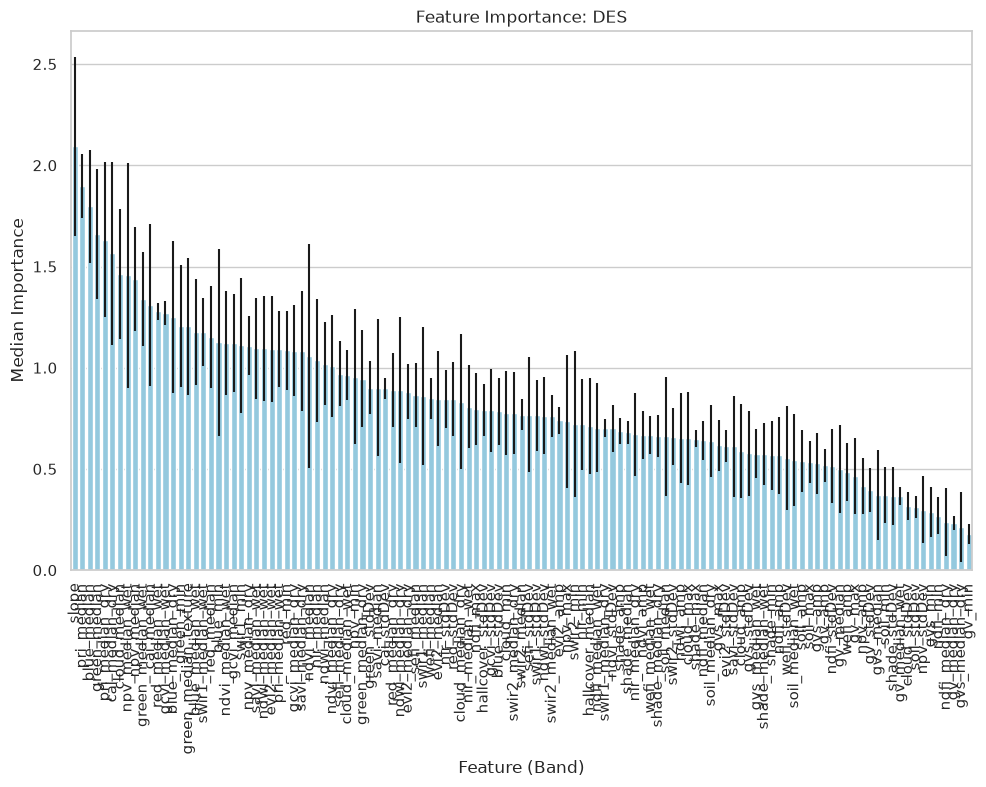

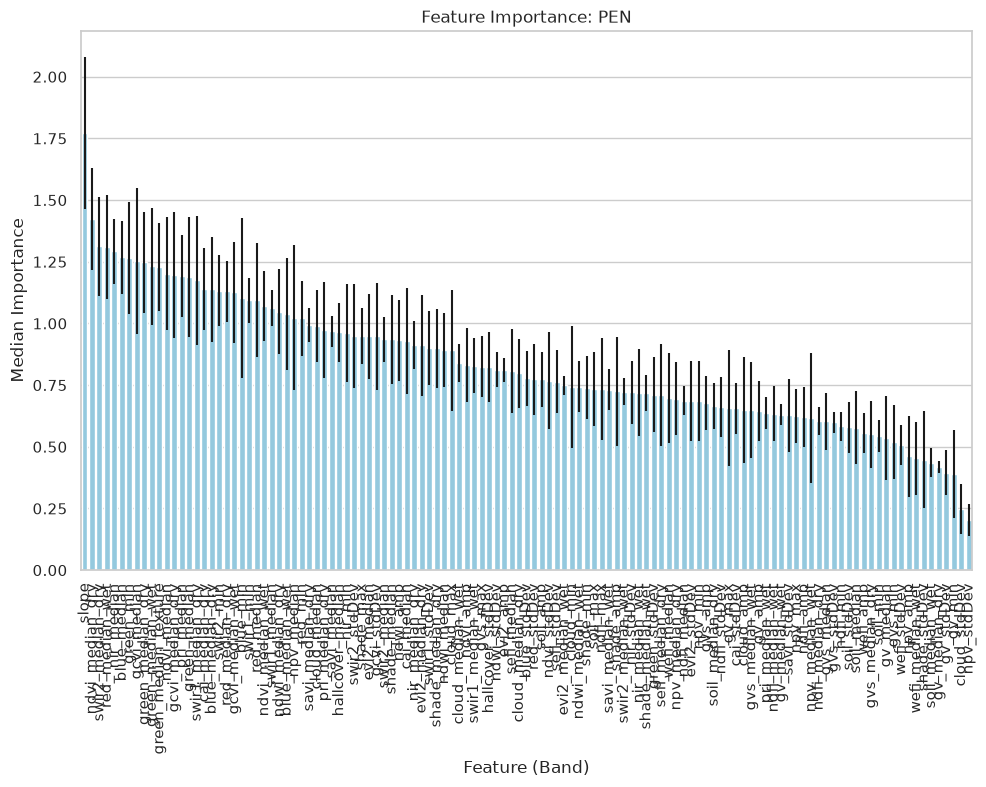

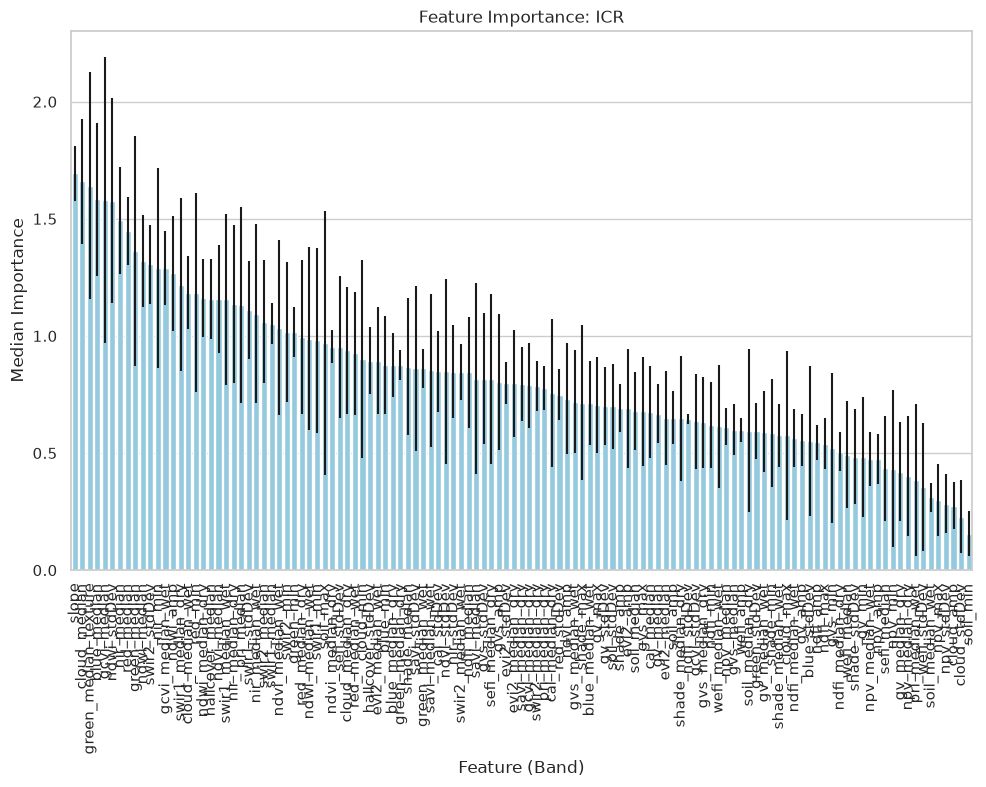

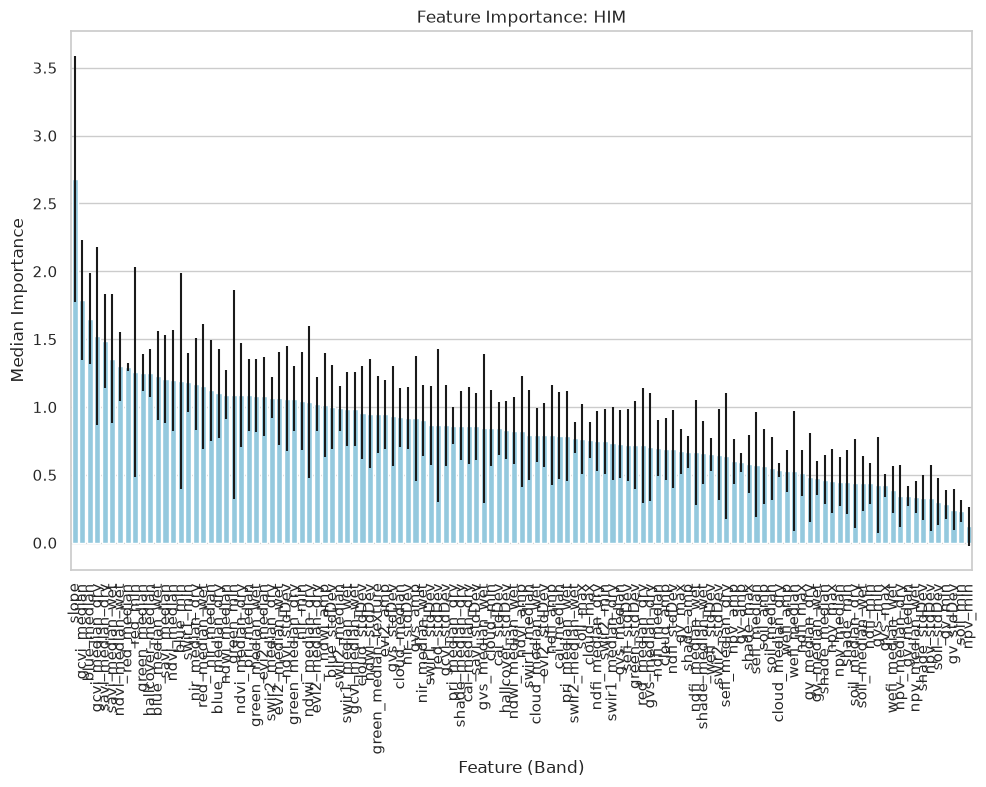

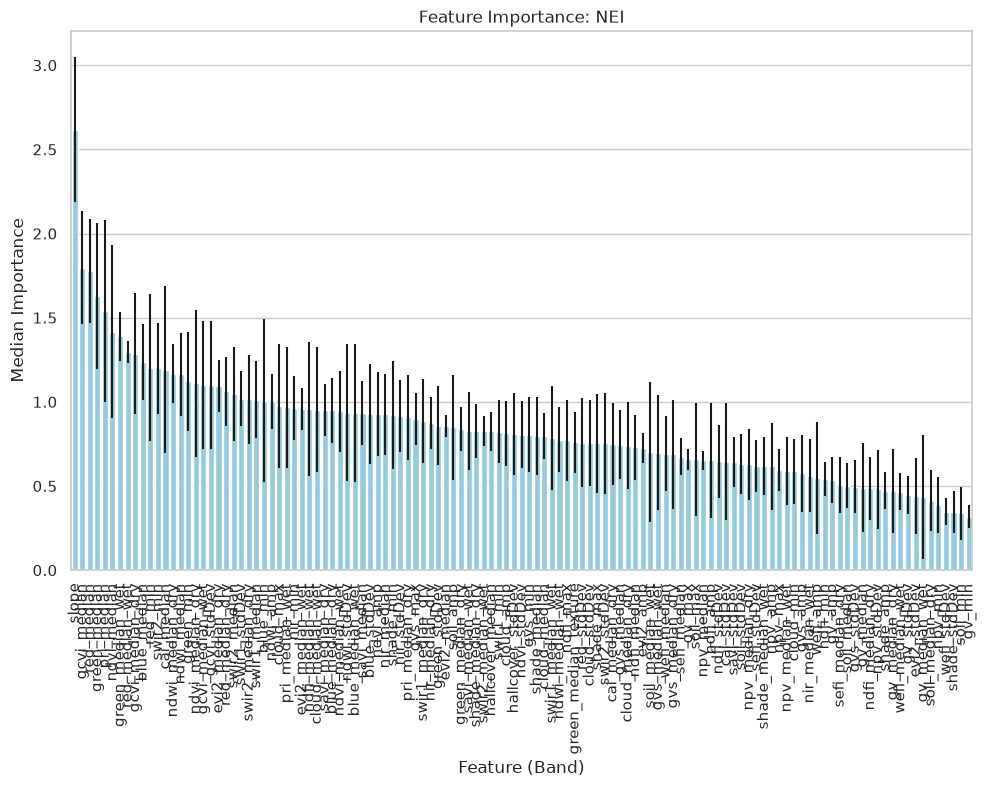

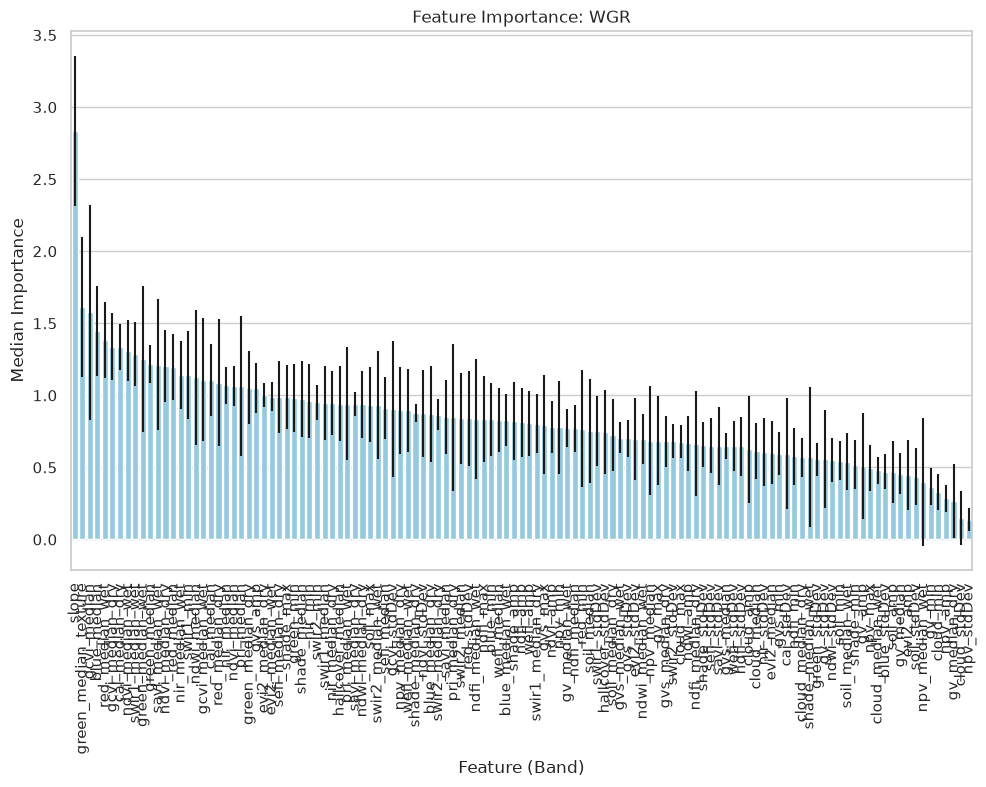

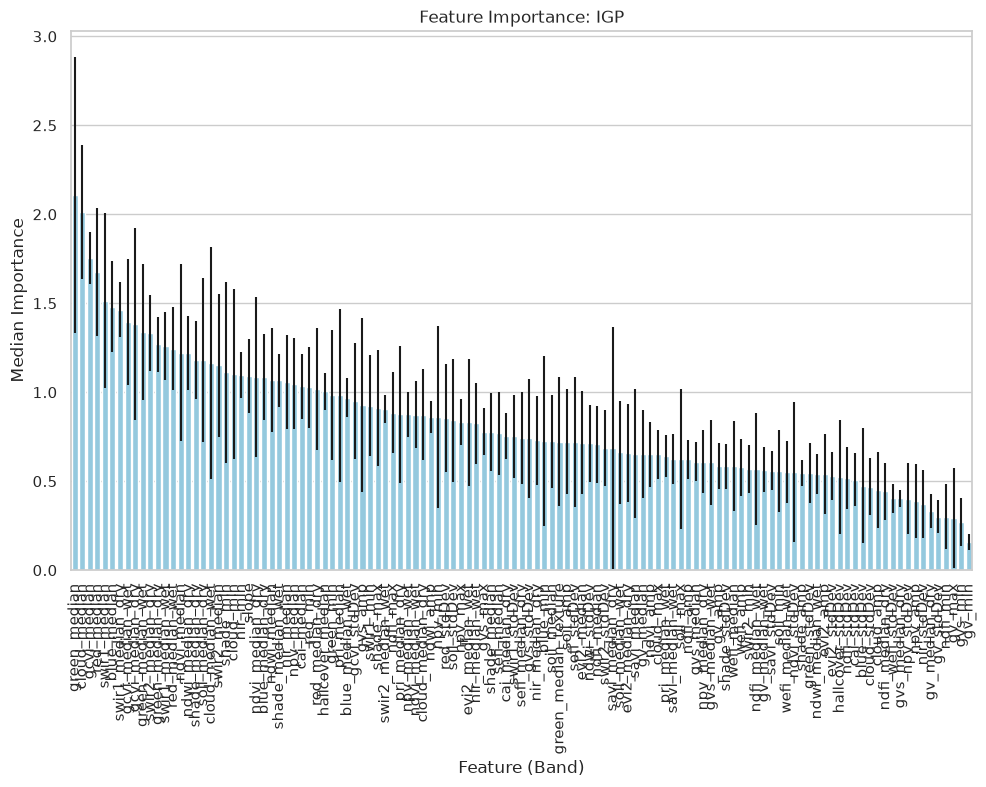

In [23]:
dir_path = 'data/feature_importance/aggregated/'
for file in os.listdir(dir_path):
    filepath = os.path.join(dir_path,file)
    region = os.path.basename(file).split('_')[2]
    features_df = pd.read_csv(filepath)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='band', 
        y='importance_median', 
        data=features_df, 
        color='skyblue', 
        yerr=features_df['importance_std']
    )
    plt.title(f'Feature Importance: {region}')
    plt.ylabel('Median Importance')
    plt.xlabel('Feature (Band)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Scenario 4

Plot results

In [21]:
scenariowise_perf_df = pd.read_csv('data/groupwise_runs_multiyear.csv')

Text(0.5, 1.0, 'F1-Weighted Score Distribution by Region and Feature Set')

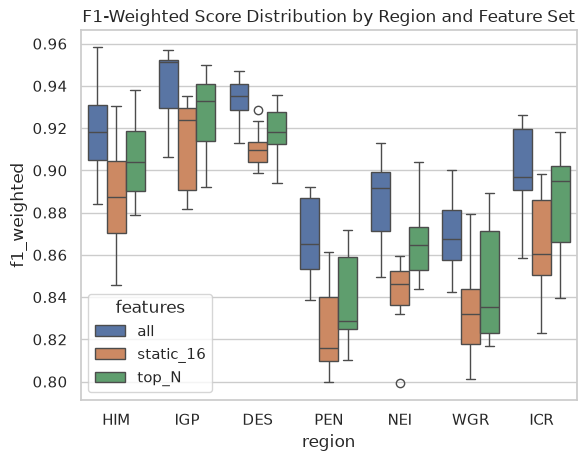

In [25]:
sns.boxplot(data=scenariowise_perf_df, x='region', y='f1_weighted',hue = 'features')
plt.title('F1-Weighted Score Distribution by Region and Feature Set')

Text(0.5, 1.0, 'F1 Macro Score Distribution by Region and Feature Set')

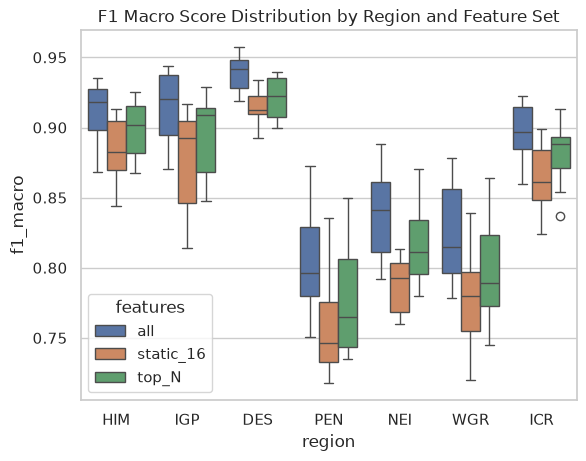

In [ ]:
sns.boxplot(data=scenariowise_perf_df, x='region', y='f1_macro',hue = 'features')
plt.title('F1-Macro Score Distribution by Region and Feature Set')

<Axes: xlabel='features', ylabel='f1_weighted'>

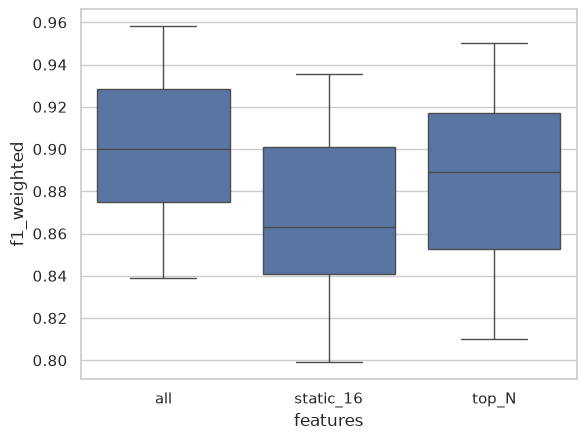

In [26]:
sns.boxplot(data=scenariowise_perf_df, x='features', y='f1_weighted')

<Axes: xlabel='features', ylabel='f1_macro'>

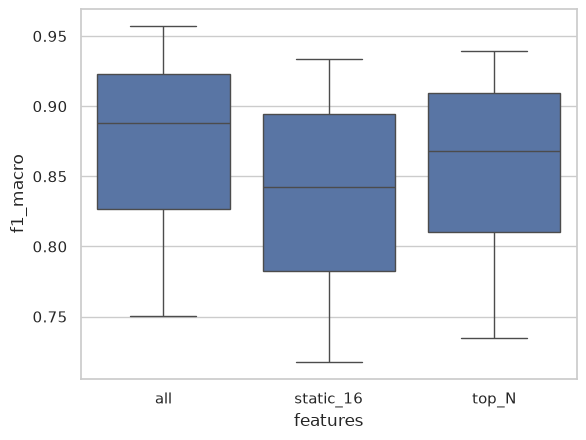

In [27]:
sns.boxplot(data=scenariowise_perf_df, x='features', y='f1_macro')

Number of features X Model performance

In [76]:
# 1. Define your experiment space
regions = ['HIM','IGP', 'DES', 'PEN', 'NEI', 'WGR', 'ICR']

region_id_map = {'HIM': 1, 'IGP': 2, 'DES': 3, 'PEN': 4, 'NEI': 5, 'WGR': 6, 'ICR': 7}

sample_version_map = {
    'HIM': '4', 'IGP': '5', 'DES': '7', 'PEN': '5', 'NEI': '5', 'WGR': '3', 'ICR': '4'
}

param_grid = {
    'sample_strategy': ['scaled'], 
    'n_trees': [50],               
    'features': ['top_N'],
    'minLeafPopulation' : [5]         
}

# Keep num_features as default
TOP_N_FEATURES = [25,30,35,40]
# TOP_N_FEATURES = [45,50]
# TOP_N_FEATURES = [70]

keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
experiment_logs = []
classes = classwise_samples_scaled_2k_10k['classification_class_code'].tolist()

for region in regions:
    for n_features in TOP_N_FEATURES:
        region_id = region_id_map[region]
        current_sample_version = sample_version_map[region]
        
        # Extract the scaled target counts for this region
        scaled_counts = classwise_samples_scaled_2k_10k[region].tolist()
        
        # Extract the default target counts for this region from the newly referenced CSV
        # (Using .tolist() assumes the rows in default_samples_df are in the exact same order as classes)
        # default_counts = default_samples_df[region].tolist()
        
        # Format lists for the EE module's load_and_balance_data()
        scaled_balance_list = [[int(c), int(s)] for c, s in zip(classes, scaled_counts)]
        # default_balance_list = [[int(c), int(s)] for c, s in zip(classes, default_counts)]

        for year in YEARS:
            for params in param_combinations:
                print(f"Executing: {region} (v{current_sample_version}) | Num_features : {n_features} |  Year {year} | Params: {params}")
                
                # Initialize the EE module 
                ee_module = EEFeatureSelectionModule(
                    region_id=region_id, 
                    year=year, 
                    sample_version_in=current_sample_version, 
                    number_of_trees=params['n_trees'],
                    min_leaf_population=params['minLeafPopulation']
                )
                
                # Apply sampling strategy
                if params['sample_strategy'] == 'scaled':
                    ee_module.load_and_balance_data(scaled_balance_list)
                # else:
                #     ee_module.load_and_balance_data(default_balance_list)
                    
                # Determine Feature List
                if params['features'] == 'all':
                    all_features = ee_module.training_partition.first().propertyNames()
                    features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
                    features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
                    trained_classifier, accuracy, f1_weighted, f1_macro,y_true, y_pred,importance_df = ee_module.evaluate_model(features_list,return_importance=True)

                    importance_df['region'] = region
                    importance_df['year'] = year
                    importance_df['sample_version'] = current_sample_version

                    # Determine if the header should be written
                    file_path = f'data/feature_importance/feature_importance_{region}_v{current_sample_version}_{year}.csv'
                    file_exists = os.path.exists(file_path)

                    # Append data dynamically
                    importance_df.to_csv(file_path, index=False)
                    # importance_df.to_csv(file_path, mode='a', index=False, header=not file_exists)
                elif params['features'] == 'top_N':
                    # Read aggregated file like feature_importance_DES_v7.csv
                    agg_file_path = f'data/feature_importance/aggregated/feature_importance_{region}_v{current_sample_version}.csv'
                    
                    if os.path.exists(agg_file_path):
                        agg_df = pd.read_csv(agg_file_path)
                        # Slice the top N features based on the aggregated median importance
                        features_list = agg_df.sort_values(by="importance_median", ascending=False)['band'].head(n_features).tolist()
                    # else:
                    #     print(f"Warning: {agg_file_path} not found. Defaulting to standard bands.")
                    #     features_list = ee_module.default_bands
                        
                        trained_classifier, accuracy, f1_weighted, f1_macro, y_true, y_pred = ee_module.evaluate_model(features_list)         
                else:
                    features_list = ee_module.default_bands
                    trained_classifier, accuracy, f1_weighted, f1_macro, y_true, y_pred = ee_module.evaluate_model(features_list)
                    
                # Train and Evaluate
                # trained_classifier, accuracy, f1_weighted, y_true, y_pred = ee_module.evaluate_model(features_list)
                
                # Log results
                experiment_logs.append({
                    'region': region,
                    'year': year,
                    'sample_version': current_sample_version,
                    'sample_strategy': params['sample_strategy'],
                    'n_trees': params['n_trees'],
                    'features': params['features'],
                    'accuracy': accuracy,
                    'f1_weighted': f1_weighted,
                    'f1_macro': f1_macro,
                    'num_features': n_features
                })

# Convert to DataFrame
results_df = pd.DataFrame(experiment_logs)

Executing: HIM (v4) | Num_features : 25 |  Year 1995 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: HIM (v4) | Num_features : 25 |  Year 1998 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: HIM (v4) | Num_features : 25 |  Year 2001 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: HIM (v4) | Num_features : 25 |  Year 2004 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'features': 'top_N', 'minLeafPopulation': 5}
Calculating Level 1 class distributions (this may take a moment)...
Executing: HIM (v4) | Num_features : 25 |  Year 2007 | Params: {'sample_strategy': 'scaled', 'n_trees': 50, 'feature

In [77]:
results_path = os.path.join('data', 'groupwise_runs_multiyear_n_features.csv')

# Explicitly check for file existence to toggle the header
file_exists = os.path.exists(results_path)
file_exists

True

In [78]:
# Append to CSV
results_df.to_csv(
    results_path, 
    mode='a', 
    index=False, 
    header=not file_exists
)

In [79]:
n_features_df = pd.read_csv('data/groupwise_runs_multiyear_n_features.csv')

In [80]:
n_features_df.shape

(700, 10)

In [ ]:
# n_features_20_df = pd.read_csv('data/groupwise_runs_multiyear.csv')

In [ ]:
# n_features_20_df = n_features_20_df[n_features_20_df['features'] == 'top_N']

In [ ]:
# n_features_20_df.shape

(70, 10)

In [ ]:
# n_features_20_df['num_features'] = 20

In [ ]:
# n_features_df.columns

Index(['region', 'year', 'sample_version', 'sample_strategy', 'n_trees',
       'features', 'accuracy', 'f1_weighted', 'f1_macro', 'num_features'],
      dtype='str')

In [ ]:
# n_features_df = pd.concat([n_features_df, n_features_20_df], ignore_index=True)

In [ ]:
# n_features_20_df.to_csv('data/groupwise_runs_multiyear_n_features.csv', index=False)

* Add the "all features case"

In [56]:
# all_features_df = pd.read_csv('data/groupwise_runs_multiyear.csv')

In [ ]:
# all_features_df[all_features_df['features'] == 'all']

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted,f1_macro
0,HIM,1995,4,scaled,50,all,0.887805,0.884191,0.867944
2,HIM,1998,4,scaled,50,all,0.929641,0.928793,0.921005
4,HIM,2001,4,scaled,50,all,0.917445,0.917235,0.915063
6,HIM,2004,4,scaled,50,all,0.959055,0.958341,0.935246
8,HIM,2007,4,scaled,50,all,0.939908,0.938754,0.929994
...,...,...,...,...,...,...,...,...,...
130,ICR,2010,4,scaled,50,all,0.889336,0.889295,0.893997
132,ICR,2013,4,scaled,50,all,0.919355,0.918732,0.911063
134,ICR,2016,4,scaled,50,all,0.924335,0.921443,0.915778
136,ICR,2019,4,scaled,50,all,0.927419,0.926377,0.922807


In [ ]:
# all_features_df = all_features_df[all_features_df['features'] == 'all']

In [ ]:
# all_features_df['num_features'] = 119

In [ ]:
# all_features_df

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted,f1_macro,num_features
0,HIM,1995,4,scaled,50,all,0.887805,0.884191,0.867944,119
2,HIM,1998,4,scaled,50,all,0.929641,0.928793,0.921005,119
4,HIM,2001,4,scaled,50,all,0.917445,0.917235,0.915063,119
6,HIM,2004,4,scaled,50,all,0.959055,0.958341,0.935246,119
8,HIM,2007,4,scaled,50,all,0.939908,0.938754,0.929994,119
...,...,...,...,...,...,...,...,...,...,...
130,ICR,2010,4,scaled,50,all,0.889336,0.889295,0.893997,119
132,ICR,2013,4,scaled,50,all,0.919355,0.918732,0.911063,119
134,ICR,2016,4,scaled,50,all,0.924335,0.921443,0.915778,119
136,ICR,2019,4,scaled,50,all,0.927419,0.926377,0.922807,119


In [64]:
n_features_df = pd.concat([n_features_df, all_features_df], ignore_index=True)

In [ ]:
# n_features_df = pd.concat([n_features_df, all_features_df], ignore_index=True)

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted,f1_macro,num_features
0,HIM,1995,4,scaled,50,top_N,0.881301,0.878672,0.867297,20
1,HIM,1998,4,scaled,50,top_N,0.919162,0.918586,0.913565,20
2,HIM,2001,4,scaled,50,top_N,0.900312,0.900332,0.901309,20
3,HIM,2004,4,scaled,50,top_N,0.938583,0.938196,0.925436,20
4,HIM,2007,4,scaled,50,top_N,0.924499,0.921982,0.902723,20
...,...,...,...,...,...,...,...,...,...,...
415,ICR,2010,4,scaled,50,all,0.889336,0.889295,0.893997,119
416,ICR,2013,4,scaled,50,all,0.919355,0.918732,0.911063,119
417,ICR,2016,4,scaled,50,all,0.924335,0.921443,0.915778,119
418,ICR,2019,4,scaled,50,all,0.927419,0.926377,0.922807,119


In [ ]:
# n_features_df.to_csv('data/groupwise_runs_multiyear_n_features.csv', index=False)

In [ ]:
# n_features_df.shape

(420, 10)

In [68]:
n_features_df = pd.read_csv('data/groupwise_runs_multiyear_n_features.csv')

In [69]:
n_features_df

,region,year,sample_version,sample_strategy,n_trees,features,accuracy,f1_weighted,f1_macro,num_features
0,HIM,1995,4,scaled,50,top_N,0.881301,0.878672,0.867297,20
1,HIM,1998,4,scaled,50,top_N,0.919162,0.918586,0.913565,20
2,HIM,2001,4,scaled,50,top_N,0.900312,0.900332,0.901309,20
3,HIM,2004,4,scaled,50,top_N,0.938583,0.938196,0.925436,20
4,HIM,2007,4,scaled,50,top_N,0.924499,0.921982,0.902723,20
...,...,...,...,...,...,...,...,...,...,...
415,ICR,2010,4,scaled,50,all,0.889336,0.889295,0.893997,119
416,ICR,2013,4,scaled,50,all,0.919355,0.918732,0.911063,119
417,ICR,2016,4,scaled,50,all,0.924335,0.921443,0.915778,119
418,ICR,2019,4,scaled,50,all,0.927419,0.926377,0.922807,119


<Axes: xlabel='num_features', ylabel='f1_macro'>

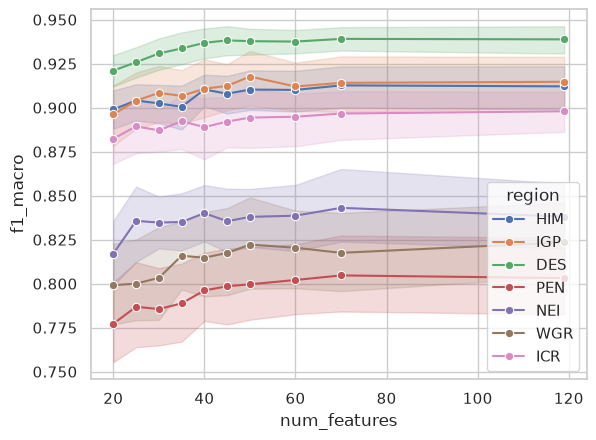

In [81]:
sns.lineplot(x = n_features_df['num_features'],
             y = n_features_df['f1_macro'],
             marker="o",
             hue = n_features_df['region'])

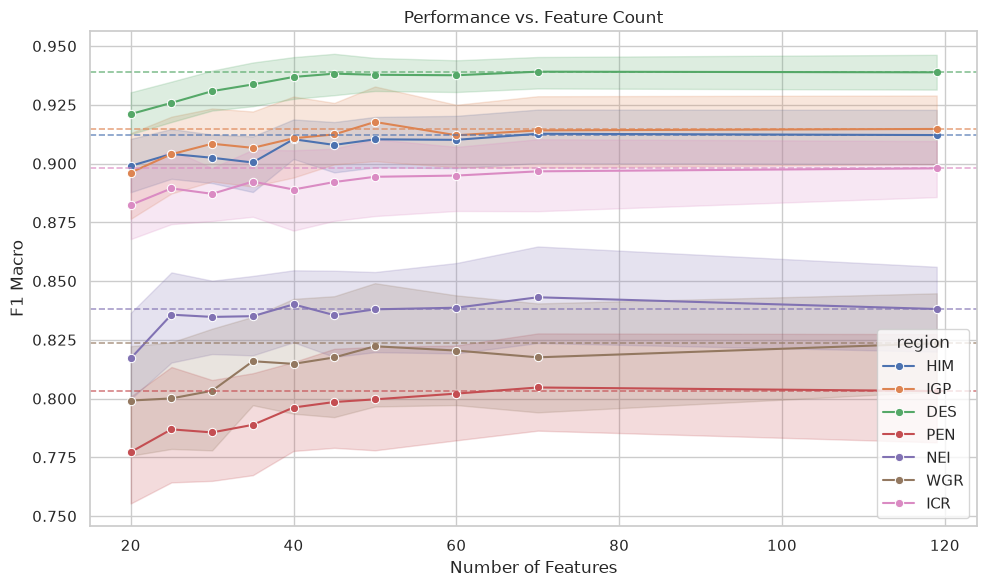

In [82]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=n_features_df,
    x="num_features",
    y="f1_macro",
    hue="region",
    marker="o",
    errorbar="ci",
)

# Extract palette colors mapped to each region by seaborn
palette = {
    line.get_label(): line.get_color()
    for line in ax.lines
    if line.get_label() in n_features_df["region"].unique()
}

# Calculate mean 119-feature performance per region
baseline_119 = (
    n_features_df[n_features_df["num_features"] == 119]
    .groupby("region")["f1_macro"]
    .mean()
)

# Overlay region-matched horizontal reference lines
for region, baseline_val in baseline_119.items():
    ax.axhline(
        y=baseline_val,
        color=palette.get(region, "gray"),
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
    )
sns.move_legend(ax, "lower right")
plt.xlabel("Number of Features")
plt.ylabel("F1 Macro")
plt.title("Performance vs. Feature Count")
plt.tight_layout()
plt.show()

In [89]:
# import plotly.express as px
# import plotly.graph_objects as go

# df = n_features_df.copy()
# # 1. Pre-aggregate across multi-year runs (mean & 95% CI)
# agg = (
#     df.groupby(["region", "num_features"])["f1_macro"]
#     .agg(mean="mean", std="std", count="count")
#     .reset_index()
# )
# agg["ci95"] = 1.96 * (agg["std"] / np.sqrt(agg["count"]))

# # 2. Extract the 119-feature mean baseline per region
# baseline_119 = (
#     agg[agg["num_features"] == 119].set_index("region")["mean"].to_dict()
# )

# fig = go.Figure()
# palette = px.colors.qualitative.Plotly
# regions = agg["region"].unique()

# for idx, region in enumerate(regions):
#     grp = agg[agg["region"] == region].sort_values("num_features")
#     color = palette[idx % len(palette)]
#     base_val = baseline_119[region]

#     # Mean trajectory with 95% CI error bars
#     fig.add_trace(
#         go.Scatter(
#             x=grp["num_features"],
#             y=grp["mean"],
#             mode="lines+markers",
#             name=region,
#             legendgroup=region,
#             line=dict(color=color, width=2),
#             marker=dict(size=6),
#             error_y=dict(
#                 type="data",
#                 array=grp["ci95"],
#                 visible=True,
#                 thickness=1.2,
#                 width=3,
#             ),
#             hovertemplate=(
#                 f"<b>{region}</b><br>"
#                 "Features: %{x}<br>"
#                 "F1 Mean: %{y:.3f} (±%{error_y.array:.3f})<extra></extra>"
#             ),
#         )
#     )

#     # Dashed 119-feature baseline locked to the same legend group
#     fig.add_trace(
#         go.Scatter(
#             x=[grp["num_features"].min(), grp["num_features"].max()],
#             y=[base_val, base_val],
#             mode="lines",
#             name=f"{region} (119 Base)",
#             legendgroup=region,
#             showlegend=False,
#             line=dict(color=color, dash="dash", width=1.2),
#             hoverinfo="skip",
#         )
#     )

# fig.update_layout(
#     title="F1 Macro vs. Number of Features (Mean ± 95% CI across Years)",
#     xaxis=dict(title="Number of Features", dtick=20),
#     yaxis=dict(title="F1 Macro"),
#     template="plotly_white",
#     hovermode="closest",
# )

# fig.show()

In [ ]:
import plotly.colors as pc
import plotly.express as px
import plotly.graph_objects as go

df = n_features_df.copy()
# 1. Pre-aggregate mean and 95% CI across annual runs
agg = (
    df.groupby(["region", "num_features"])["f1_macro"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
agg["ci95"] = 1.96 * (agg["std"] / np.sqrt(agg["count"]))

# 2. Extract baseline stats at 119 features
b119 = (
    agg[agg["num_features"] == 119]
    .set_index("region")[["mean", "ci95"]]
    .to_dict(orient="index")
)

fig = go.Figure()
palette = px.colors.qualitative.Plotly
regions = agg["region"].unique()
x_min, x_max = agg["num_features"].min(), agg["num_features"].max()

for idx, region in enumerate(regions):
    grp = agg[agg["region"] == region].sort_values("num_features")
    color = palette[idx % len(palette)]
    r, g, b = pc.hex_to_rgb(color)
    base_mean = b119[region]["mean"]
    base_ci = b119[region]["ci95"]

    # 119 Baseline: 95% CI Shaded Band
    fig.add_trace(
        go.Scatter(
            x=[x_min, x_max, x_max, x_min],
            y=[
                base_mean - base_ci,
                base_mean - base_ci,
                base_mean + base_ci,
                base_mean + base_ci,
            ],
            fill="toself",
            fillcolor=f"rgba({r},{g},{b},0.15)",
            line=dict(color="rgba(255,255,255,0)"),
            hoverinfo="skip",
            showlegend=False,
            name=f"{region} 119 CI",
            legendgroup=region,
        )
    )

    # 119 Baseline: Mean Reference Line
    fig.add_trace(
        go.Scatter(
            x=[x_min, x_max],
            y=[base_mean, base_mean],
            mode="lines",
            name=f"{region} (119 Base)",
            legendgroup=region,
            showlegend=False,
            line=dict(color=color, dash="dash", width=1.2),
            hovertemplate=(
                f"<b>{region} 119-feat Baseline</b><br>"
                f"Mean: {base_mean:.3f} (±{base_ci:.3f})<extra></extra>"
            ),
        )
    )

    # Main Curve: Mean trajectory with CI error bars
    fig.add_trace(
        go.Scatter(
            x=grp["num_features"],
            y=grp["mean"],
            mode="lines+markers",
            name=region,
            legendgroup=region,
            line=dict(color=color, width=2),
            marker=dict(size=6),
            error_y=dict(
                type="data",
                array=grp["ci95"],
                visible=True,
                thickness=1.2,
                width=3,
            ),
            hovertemplate=(
                f"<b>{region}</b><br>"
                "Features: %{x}<br>"
                "F1 Mean: %{y:.3f} (±%{error_y.array:.3f})<extra></extra>"
            ),
        )
    )

fig.update_layout(
    title="F1 Macro vs. Feature Count (with 119-Feature Baseline ±95% CI Bands)",
    xaxis=dict(title="Number of Features", dtick=20),
    yaxis=dict(title="F1 Macro"),
    template="plotly_white",
    hovermode="closest",
)

fig.show()

In [87]:
fig.write_html("data/plots/feature_performance_interactive.html", include_plotlyjs="cdn")